In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42
LABELS = ["left", "center", "right"]

pd.set_option("display.max_columns", None)

In [2]:
DATA_PATH = Path("../data/processed/newsbias_cleaned.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nTarget distribution:")
print(df["bias_rating"].value_counts())

assert df["model_text"].notna().all()
assert df["bias_rating"].notna().all()

print("\nDataset loaded and validated.")

Dataset shape: (21748, 9)
Columns: ['Unnamed: 0', 'title', 'tags', 'heading', 'source', 'text', 'bias_rating', 'model_text', 'normalized_model_text']

Target distribution:
bias_rating
left      10271
right      7225
center     4252
Name: count, dtype: int64

Dataset loaded and validated.


In [3]:
X = df["model_text"].reset_index(drop=True)
y = df["bias_rating"].reset_index(drop=True)

event_groups = df["title"].fillna("").reset_index(drop=True)
source_groups = df["source"].fillna("Unknown").reset_index(drop=True)

print("Samples:", len(X))
print("Unique event titles:", event_groups.nunique())
print("Unique sources:", source_groups.nunique())

Samples: 21748
Unique event titles: 7263
Unique sources: 465


In [4]:
X_train_random, X_test_random, y_train_random, y_test_random = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y
    )
)

In [5]:
event_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_idx_event, test_idx_event = next(
    event_splitter.split(X, y, groups=event_groups)
)

X_train_event = X.iloc[train_idx_event]
X_test_event = X.iloc[test_idx_event]
y_train_event = y.iloc[train_idx_event]
y_test_event = y.iloc[test_idx_event]

assert set(event_groups.iloc[train_idx_event]).isdisjoint(
    set(event_groups.iloc[test_idx_event])
)

In [6]:
source_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_idx_source, test_idx_source = next(
    source_splitter.split(X, y, groups=source_groups)
)

X_train_source = X.iloc[train_idx_source]
X_test_source = X.iloc[test_idx_source]
y_train_source = y.iloc[train_idx_source]
y_test_source = y.iloc[test_idx_source]

assert set(source_groups.iloc[train_idx_source]).isdisjoint(
    set(source_groups.iloc[test_idx_source])
)

In [7]:
split_data = {
    "Random": (X_train_random, X_test_random, y_train_random, y_test_random),
    "Event-disjoint": (X_train_event, X_test_event, y_train_event, y_test_event),
    "Source-disjoint": (X_train_source, X_test_source, y_train_source, y_test_source)
}

for name, (Xtr, Xte, ytr, yte) in split_data.items():
    print(f"\n{name}")
    print("Train:", len(Xtr), "| Test:", len(Xte))
    print("Test distribution:")
    print(yte.value_counts(normalize=True).round(3))


Random
Train: 17398 | Test: 4350
Test distribution:
bias_rating
left      0.472
right     0.332
center    0.196
Name: proportion, dtype: float64

Event-disjoint
Train: 17396 | Test: 4352
Test distribution:
bias_rating
left      0.471
right     0.333
center    0.197
Name: proportion, dtype: float64

Source-disjoint
Train: 18950 | Test: 2798
Test distribution:
bias_rating
center    0.482
right     0.354
left      0.164
Name: proportion, dtype: float64


In [8]:
def build_logistic_regression():
    return Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_features=100_000,
                sublinear_tf=True
            )
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ])


def build_linear_svm():
    return Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_features=100_000,
                sublinear_tf=True
            )
        ),
        (
            "classifier",
            LinearSVC(
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ])

In [10]:
def evaluate_model(model, X_train, y_train, X_test, y_test,
                   model_name, split_name):

    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    results = {
        "Model": model_name,
        "Split": split_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Macro-F1": f1_score(
            y_test, predictions,
            labels=LABELS,
            average="macro",
            zero_division=0
        ),
        "Macro-Precision": precision_score(
            y_test, predictions,
            labels=LABELS,
            average="macro",
            zero_division=0
        ),
        "Macro-Recall": recall_score(
            y_test, predictions,
            labels=LABELS,
            average="macro",
            zero_division=0
        )
    }

    print(f"\n{'=' * 12} {model_name} | {split_name} {'=' * 12}")
    print("Accuracy:", round(results["Accuracy"], 4))
    print("Macro-F1:", round(results["Macro-F1"], 4))

    print("\nClassification report:")
    print(classification_report(
        y_test,
        predictions,
        labels=LABELS,
        zero_division=0
    ))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        labels=LABELS,
        display_labels=["Left", "Center", "Right"],
        cmap="Blues"
    )
    plt.title(f"{model_name} — {split_name}")
    plt.tight_layout()
    plt.show()

    return results, model


============ Logistic Regression | Random ============
Accuracy: 0.4908
Macro-F1: 0.465

Classification report:
              precision    recall  f1-score   support

        left       0.59      0.56      0.57      2054
      center       0.34      0.39      0.36       851
       right       0.46      0.46      0.46      1445

    accuracy                           0.49      4350
   macro avg       0.46      0.47      0.46      4350
weighted avg       0.50      0.49      0.49      4350



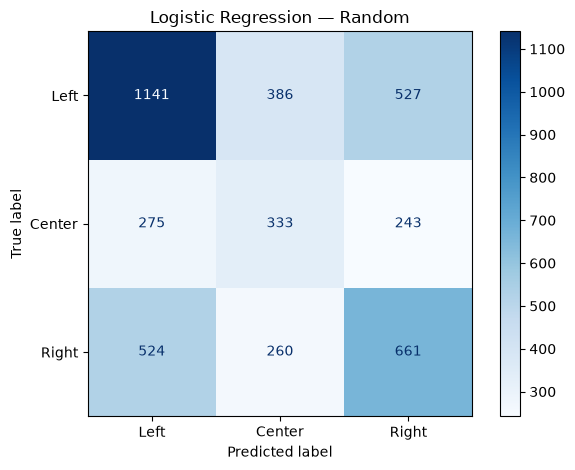


============ Linear SVM | Random ============
Accuracy: 0.4844
Macro-F1: 0.4395

Classification report:
              precision    recall  f1-score   support

        left       0.56      0.61      0.58      2054
      center       0.34      0.27      0.30       851
       right       0.44      0.43      0.43      1445

    accuracy                           0.48      4350
   macro avg       0.45      0.44      0.44      4350
weighted avg       0.48      0.48      0.48      4350



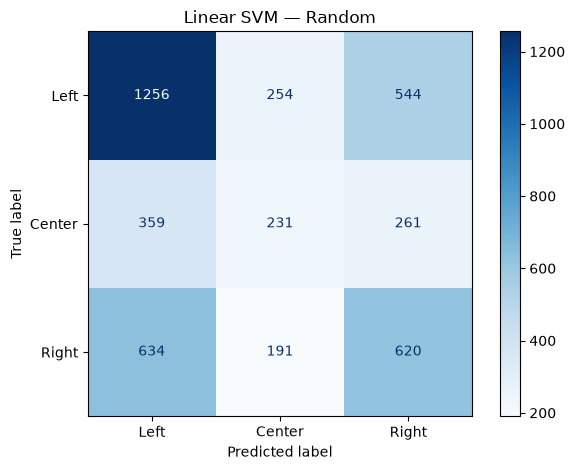


============ Logistic Regression | Event-disjoint ============
Accuracy: 0.5237
Macro-F1: 0.5011

Classification report:
              precision    recall  f1-score   support

        left       0.62      0.57      0.59      2048
      center       0.38      0.44      0.41       856
       right       0.50      0.50      0.50      1448

    accuracy                           0.52      4352
   macro avg       0.50      0.51      0.50      4352
weighted avg       0.53      0.52      0.53      4352



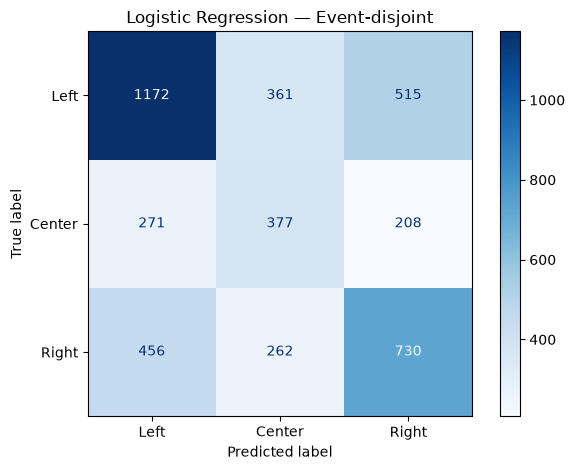


============ Linear SVM | Event-disjoint ============
Accuracy: 0.5448
Macro-F1: 0.5047

Classification report:
              precision    recall  f1-score   support

        left       0.60      0.66      0.63      2048
      center       0.42      0.34      0.38       856
       right       0.52      0.50      0.51      1448

    accuracy                           0.54      4352
   macro avg       0.51      0.50      0.50      4352
weighted avg       0.54      0.54      0.54      4352



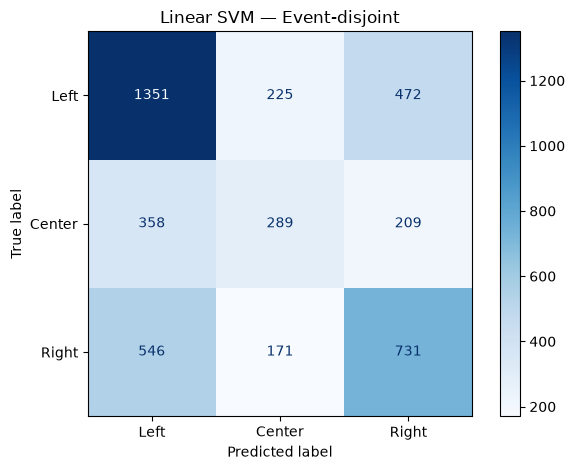


============ Logistic Regression | Source-disjoint ============
Accuracy: 0.2763
Macro-F1: 0.2775

Classification report:
              precision    recall  f1-score   support

        left       0.12      0.37      0.18       459
      center       0.45      0.17      0.24      1349
       right       0.45      0.38      0.41       990

    accuracy                           0.28      2798
   macro avg       0.34      0.31      0.28      2798
weighted avg       0.39      0.28      0.29      2798



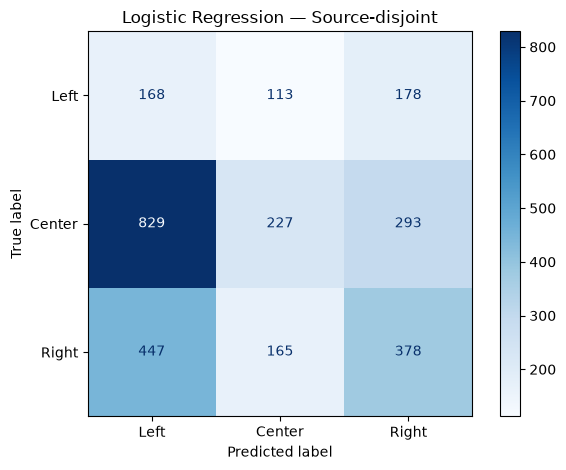


============ Linear SVM | Source-disjoint ============
Accuracy: 0.2491
Macro-F1: 0.2482

Classification report:
              precision    recall  f1-score   support

        left       0.13      0.47      0.20       459
      center       0.41      0.09      0.15      1349
       right       0.43      0.36      0.39       990

    accuracy                           0.25      2798
   macro avg       0.32      0.31      0.25      2798
weighted avg       0.37      0.25      0.24      2798



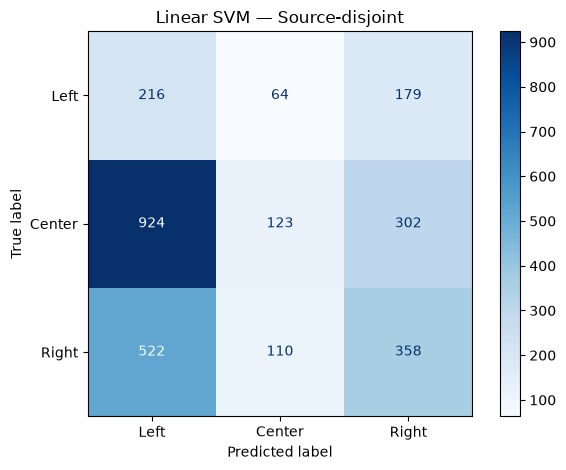

In [11]:
model_builders = {
    "Logistic Regression": build_logistic_regression,
    "Linear SVM": build_linear_svm
}

all_results = []
trained_models = {}

for split_name, (Xtr, Xte, ytr, yte) in split_data.items():

    for model_name, builder in model_builders.items():

        model = builder()

        result, trained_model = evaluate_model(
            model,
            Xtr,
            ytr,
            Xte,
            yte,
            model_name,
            split_name
        )

        all_results.append(result)
        trained_models[(model_name, split_name)] = trained_model

In [13]:
results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    by=["Split", "Macro-F1"],
    ascending=[True, False]
).reset_index(drop=True)

display(results_df.round(4))

,Model,Split,Accuracy,Macro-F1,Macro-Precision,Macro-Recall
0,Linear SVM,Event-disjoint,0.5448,0.5047,0.5129,0.5007
1,Logistic Regression,Event-disjoint,0.5237,0.5011,0.4989,0.5056
2,Logistic Regression,Random,0.4908,0.4650,0.4634,0.4681
3,Linear SVM,Random,0.4844,0.4395,0.4451,0.4373
4,Logistic Regression,Source-disjoint,0.2763,0.2775,0.3370,0.3054
5,Linear SVM,Source-disjoint,0.2491,0.2482,0.3236,0.3078


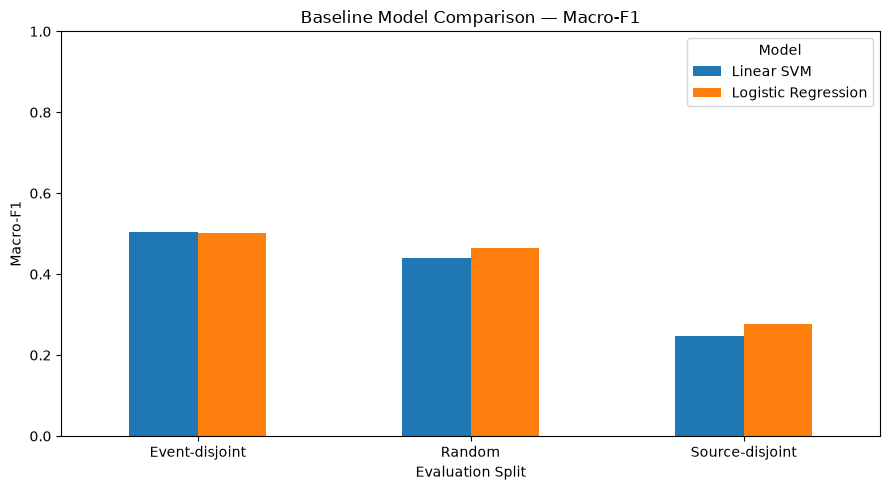

In [14]:
pivot_f1 = results_df.pivot(
    index="Split",
    columns="Model",
    values="Macro-F1"
)

ax = pivot_f1.plot(
    kind="bar",
    figsize=(9, 5),
    ylim=(0, 1),
    rot=0
)

ax.set_title("Baseline Model Comparison — Macro-F1")
ax.set_ylabel("Macro-F1")
ax.set_xlabel("Evaluation Split")
ax.legend(title="Model")
plt.tight_layout()
plt.show()

In [15]:
OUTPUT_DIR = Path("../results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_PATH = OUTPUT_DIR / "baseline_comparison.csv"

results_df.to_csv(RESULTS_PATH, index=False)

print("Results saved to:", RESULTS_PATH.resolve())

Results saved to: C:\Users\ADMIN\Desktop\News Bias Detection\news-bias-detection\results\baseline_comparison.csv
